# Lecture — Decision Trees

**Context:** Classroom theory (not a graded lab). Graded ID3 work remains in Practical 05.  
**Kernel:** `ml-lab-kernel`

### Agenda

1. Impurity: **entropy vs Gini** (same split, different numbers).
2. **ID3 vs CART**: multiway IG vs binary Gini/entropy + numeric thresholds.
3. **Continuous features**: exhaustive midpoint search.
4. **Pruning**: pre-pruning vs cost-complexity $\alpha$.
5. **Classification vs regression** trees and visualizations.

---

## 1. Impurity measures

For a node $S$ with class probabilities $p_k$, $k=1,\ldots,K$:

**Shannon entropy (bits)**

$$
H(S)=-\sum_k p_k\log_2 p_k
\quad(0\log 0:=0).
$$

**Gini impurity**

$$
G(S)=1-\sum_k p_k^{2}.
$$

Both are $0$ on a pure node. For two classes, $H$ peaks at $1$ bit when $p=1/2$; Gini peaks at $1/2$. They usually **rank the same splits**; Gini is slightly cheaper (no logs) and is CART’s default.


## Colab 1-click header (skip upload on a campus PC)

**Google Colab**

1. Runtime → Run all (or run this cell, then **DATASET CONFIG**).
2. Own CSV: **upload** when prompted, or mount Drive and set `COLAB_DRIVE_CSV` in the config cell.
3. No file: the lab loader falls back to a public URL / sklearn.

**Local Jupyter (`ml-lab-kernel`)** — this cell only reports the runtime; packages should already be installed.


In [1]:
# --- Colab / local compatibility (safe to run everywhere) ---
from __future__ import annotations

import sys
from pathlib import Path

from IPython.display import HTML, display

IN_COLAB = "google.colab" in sys.modules


def _banner(text: str, bg: str = "#0f766e") -> None:
    display(
        HTML(
            f'<div style="background:{bg};color:#fff;padding:10px 14px;'
            f"border-radius:8px;font-family:Segoe UI,sans-serif;"
            f'font-weight:600;margin:6px 0;">{text}</div>'
        )
    )


def _rule(title: str = "") -> None:
    bar = "=" * 72
    if title:
        print(f"\n{bar}\n {title}\n{bar}")
    else:
        print(bar)


_banner("0 · Runtime")
print(f"Colab detected: {IN_COLAB}  |  Python {sys.version.split()[0]}")

if IN_COLAB:
    get_ipython().run_line_magic(
        "pip", "install -q numpy pandas matplotlib seaborn scikit-learn"
    )
    print("Colab: packages checked via %pip.")
else:
    print("Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.")


def colab_upload_to(dest: Path) -> Path | None:
    """1-click CSV upload on Colab."""
    if not IN_COLAB:
        return None
    from google.colab import files  # type: ignore

    uploaded = files.upload()
    if not uploaded:
        return None
    name, blob = next(iter(uploaded.items()))
    dest = dest if dest.suffix else dest / name
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(blob)
    print(f"Saved upload -> {dest}")
    return dest


def colab_mount_drive() -> Path | None:
    if not IN_COLAB:
        return None
    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")
    root = Path("/content/drive/MyDrive")
    return root if root.exists() else None


Colab detected: False  |  Python 3.14.0
Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.


## DATASET CONFIG BLOCK — edit this cell to swap your CSV

```text
  DATA_PATH  ──►  TARGET_COLUMN  ──►  DROP_COLUMNS (IDs, names, …)
       │                 │
       └── path relative to this notebook
```

> **Why this matters:** the model does not guess the label column. A wrong `TARGET_COLUMN` is a wrong experiment.


In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  DATASET CONFIG — edit this block to use your own CSV                ║
# ╚══════════════════════════════════════════════════════════════════════╝

DATA_PATH = ''
TARGET_COLUMN = 'species'
DROP_COLUMNS = []

# Colab-only (ignored locally):
COLAB_DRIVE_CSV = None  # e.g. "/content/drive/MyDrive/my_data.csv"
COLAB_OFFER_UPLOAD = True
USE_SKLEARN_IRIS = True  # lecture default: no CSV required

from pathlib import Path as _Path

print("=" * 72)
print(" DATASET CONFIG")
print("=" * 72)
print(f"DATA_PATH       = {DATA_PATH}")
print(f"TARGET_COLUMN   = {TARGET_COLUMN}")
print(f"DROP_COLUMNS    = {DROP_COLUMNS}")
_p = _Path(DATA_PATH)
print(f"local file exists: {_p.is_file()} ({_p.resolve() if _p.exists() else _p})")


 DATASET CONFIG
DATA_PATH       = 
TARGET_COLUMN   = species
DROP_COLUMNS    = []
local file exists: False (D:\LiamCodes\parul-mtech-coding\ml-practical\theory_class_notebooks\decision_trees)


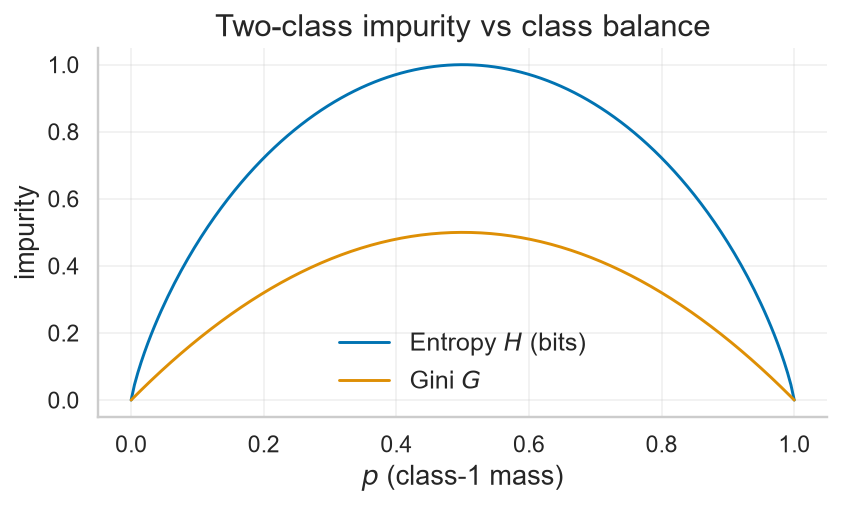

In [3]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (14, 7),   # why: large on-screen figures for lab projection / PDF
    "figure.dpi": 140,           # why: high-DPI rendering (sharp saved outputs)
    "savefig.dpi": 300,          # why: print-quality exports
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
pd.set_option("display.max_columns", 25)  # why: wide tables stay readable in the output pane
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", 40)


def entropy_bin(p: np.ndarray) -> np.ndarray:
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))


def gini_bin(p: np.ndarray) -> np.ndarray:
    return 1.0 - (p**2 + (1 - p) ** 2)


p = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(p, entropy_bin(p), label=r"Entropy $H$ (bits)")
ax.plot(p, gini_bin(p), label=r"Gini $G$")
ax.set_xlabel(r"$p$ (class-1 mass)")
ax.set_ylabel("impurity")
ax.set_title("Two-class impurity vs class balance")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


def _rule(title: str = "") -> None:
    bar = "=" * 72
    if title:
        print(f"\n{bar}\n {title}\n{bar}")
    else:
        print(bar)


## 2. ID3 vs CART (lecture map)

| | **ID3** (Quinlan 1986) | **CART** (Breiman et al.) |
|--|------------------------|---------------------------|
| Split score | Information gain $\mathrm{IG}=H(S)-\sum_v \frac{|S_v|}{|S|}H(S_v)$ | Gini (or entropy) **decrease**; regression: MSE decrease |
| Branching | **Multiway** on a categorical attribute | **Always binary** |
| Numerics | Originally discrete (C4.5 later added thresholds) | Sorted unique values; try midpoints $t$ |
| Missing / pruning | Weak / none in textbook ID3 | Surrogates (classic CART); cost-complexity pruning |
| sklearn | No multiway ID3 estimator | `DecisionTreeClassifier` / `Regressor` is CART-style binary |

**Gain-ratio (C4.5)** $\mathrm{IG}/H_{\mathrm{split}}$ penalises high-cardinality attributes — ID3’s known bias.

sklearn `criterion='entropy'` is **CART + entropy**, not multiway ID3.


## 3. Continuous features

For feature $j$ and candidate $t$, split $\{x_j\le t\}$ vs $\{x_j>t\}$. Candidates: midpoints between consecutive **sorted unique** training values. Score = weighted impurity drop. Complexity $O(n\log n)$ per feature after sorting.

Below: one numeric axis, two classes — Gini vs entropy pick the **same** cut on this toy.



 cell output
Gini t* = 1.2317 gain 0.4756
Entropy t* = 1.2317 gain 0.9152


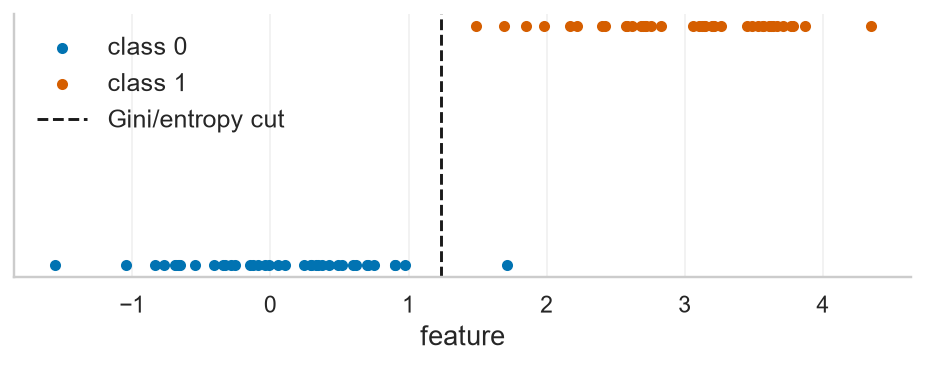

In [4]:
_rule("cell output")
rng = np.random.default_rng(SEED)
x = np.concatenate([rng.normal(0.0, 0.8, 40), rng.normal(3.0, 0.9, 40)])
y = np.array([0] * 40 + [1] * 40)
order = np.argsort(x)
x, y = x[order], y[order]


def best_threshold(x, y, kind: str):
    best_t, best_s = None, -np.inf
    n = len(y)
    for i in range(1, n):
        if x[i] == x[i - 1]:
            continue
        t = 0.5 * (x[i - 1] + x[i])
        left, right = y[x <= t], y[x > t]
        if kind == "gini":
            def imp(a):
                p = a.mean() if len(a) else 0.5
                return 1 - p**2 - (1 - p) ** 2
        else:
            def imp(a):
                p = np.clip(a.mean() if len(a) else 0.5, 1e-12, 1 - 1e-12)
                return float(-(p * np.log2(p) + (1 - p) * np.log2(1 - p)))
        p0 = y.mean()
        i0 = (1 - p0**2 - (1 - p0) ** 2) if kind == "gini" else entropy_bin(np.array([p0]))[0]
        s = i0 - (len(left) / n) * imp(left) - (len(right) / n) * imp(right)
        if s > best_s:
            best_s, best_t = s, t
    return best_t, best_s


tg, sg = best_threshold(x, y, "gini")
te, se = best_threshold(x, y, "entropy")
print("Gini t* =", round(tg, 4), "gain", round(sg, 4))
print("Entropy t* =", round(te, 4), "gain", round(se, 4))

fig, ax = plt.subplots(figsize=(6.8, 2.8))
ax.scatter(x[y == 0], np.zeros_like(x[y == 0]), c="C0", s=22, label="class 0")
ax.scatter(x[y == 1], np.ones_like(x[y == 1]) * 0.08, c="C3", s=22, label="class 1")
ax.axvline(tg, color="k", ls="--", label="Gini/entropy cut")
ax.set_yticks([])
ax.set_xlabel("feature")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


## 4. Classification tree (Iris) — `plot_tree`



 cell output
gini test acc 0.895
entropy test acc 0.895


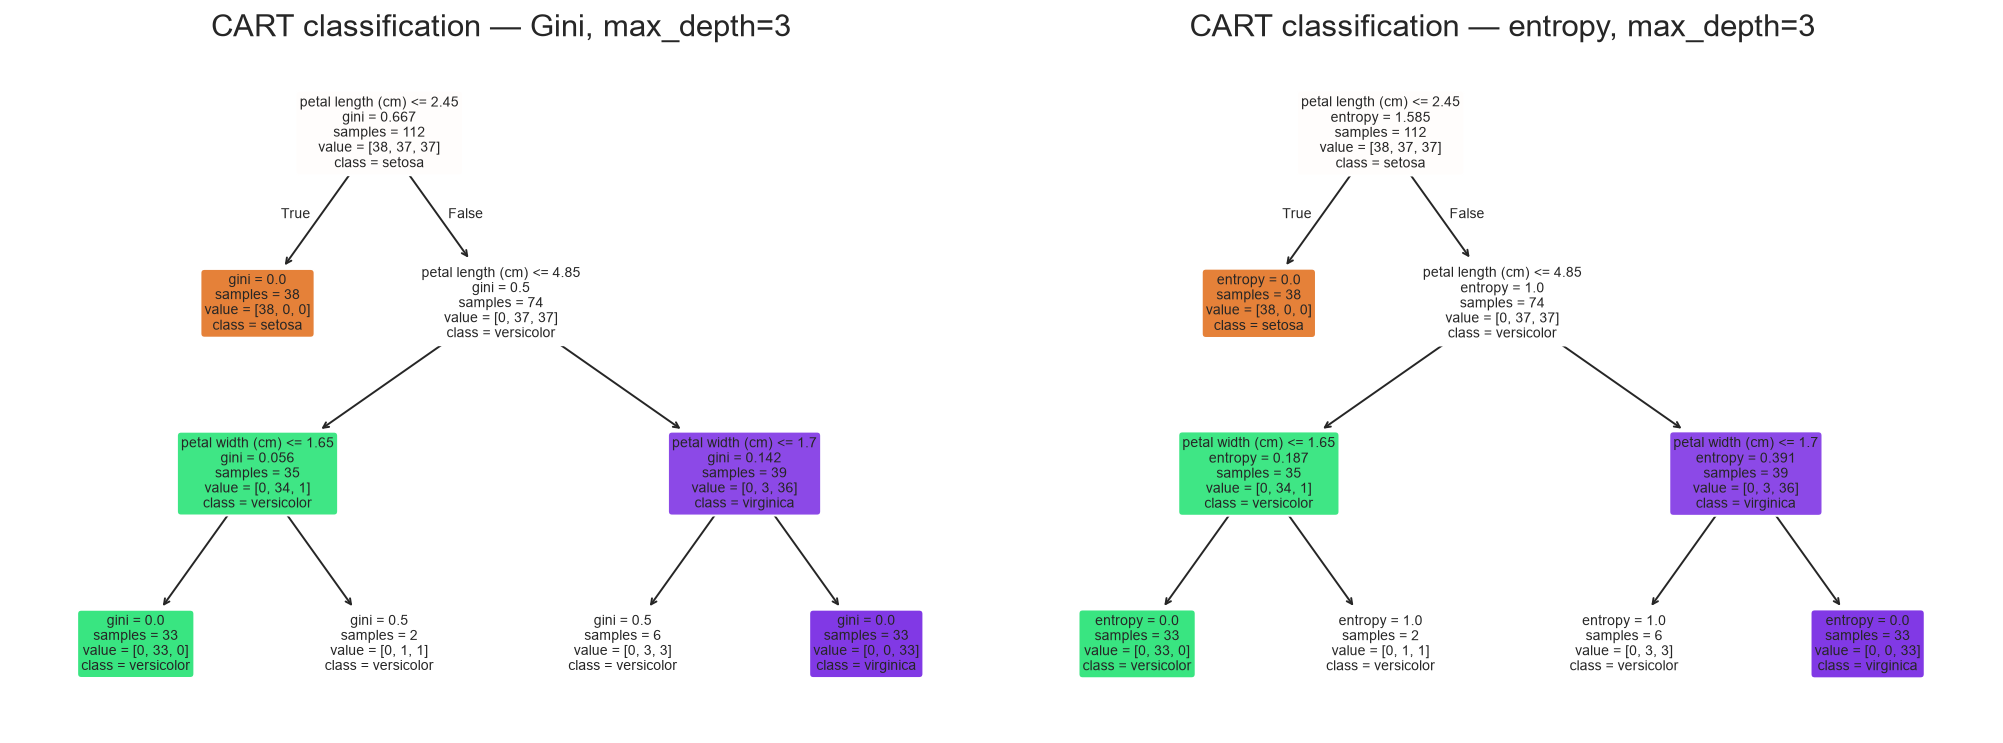

In [5]:
_rule("cell output")
iris = load_iris(as_frame=True)
X_c, y_c = iris.data, iris.target
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_c, y_c, test_size=0.25, random_state=SEED, stratify=y_c)

clf_gini = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=SEED)
clf_ent = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=SEED)
clf_gini.fit(Xc_tr, yc_tr)
clf_ent.fit(Xc_tr, yc_tr)
print("gini test acc", round(accuracy_score(yc_te, clf_gini.predict(Xc_te)), 3))
print("entropy test acc", round(accuracy_score(yc_te, clf_ent.predict(Xc_te)), 3))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.5))
plot_tree(clf_gini, feature_names=list(X_c.columns), class_names=list(iris.target_names), filled=True, rounded=True, fontsize=7, ax=axes[0])
axes[0].set_title("CART classification — Gini, max_depth=3")
plot_tree(clf_ent, feature_names=list(X_c.columns), class_names=list(iris.target_names), filled=True, rounded=True, fontsize=7, ax=axes[1])
axes[1].set_title("CART classification — entropy, max_depth=3")
fig.tight_layout()
plt.show()


## 5. Pruning

**Pre-pruning (stop early):** `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes`. Cheap, may underfit.

**Post-pruning (cost-complexity):** grow a large tree $T_{\max}$, then a nested sequence $T(\alpha)$ minimising

$$
R_\alpha(T)=R(T)+\alpha\,|T|,
$$
where $R(T)$ is resubstitution loss (misclassification or MSE) and $|T|$ is the number of leaves. sklearn: `cost_complexity_pruning_path`, then pick $\alpha$ by CV (`ccp_alpha`).



 cell output


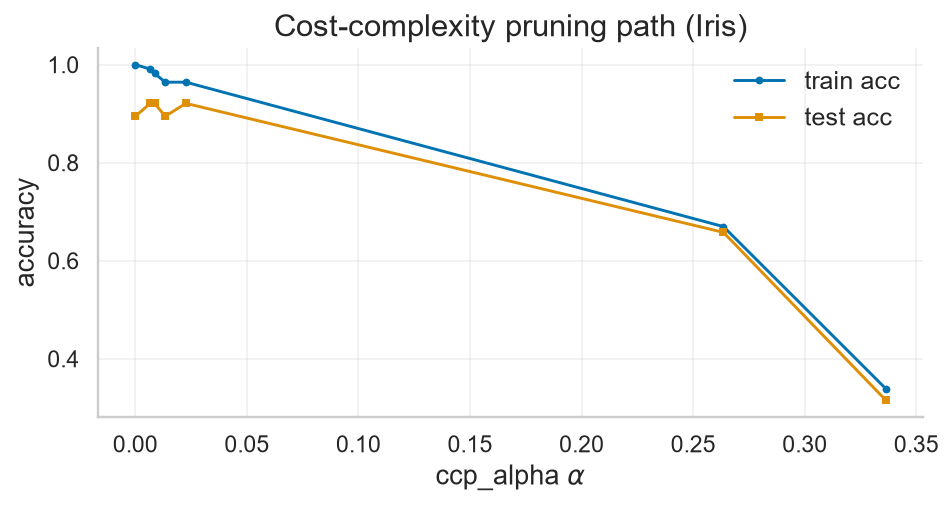

unpruned leaves 9 train 1.0 test 0.895
stump-like last alpha leaves 1 test 0.316


In [6]:
_rule("cell output")
deep = DecisionTreeClassifier(random_state=SEED)
deep.fit(Xc_tr, yc_tr)
path = deep.cost_complexity_pruning_path(Xc_tr, yc_tr)
ccp_alphas = path.ccp_alphas
train_acc, test_acc, n_leaves = [], [], []
for a in ccp_alphas:
    t = DecisionTreeClassifier(random_state=SEED, ccp_alpha=a).fit(Xc_tr, yc_tr)
    train_acc.append(accuracy_score(yc_tr, t.predict(Xc_tr)))
    test_acc.append(accuracy_score(yc_te, t.predict(Xc_te)))
    n_leaves.append(t.get_n_leaves())

fig, ax = plt.subplots(figsize=(7.0, 3.8))
ax.plot(ccp_alphas, train_acc, marker="o", ms=3, label="train acc")
ax.plot(ccp_alphas, test_acc, marker="s", ms=3, label="test acc")
ax.set_xlabel(r"ccp_alpha $\alpha$")
ax.set_ylabel("accuracy")
ax.set_title("Cost-complexity pruning path (Iris)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
print("unpruned leaves", deep.get_n_leaves(), "train", round(train_acc[0], 3), "test", round(test_acc[0], 3))
print("stump-like last alpha leaves", n_leaves[-1], "test", round(test_acc[-1], 3))


## 6. Regression trees

Split score: decrease in **MSE** (or MAE in some implementations). Leaf prediction = **mean** of $y$ in the node (MSE-optimal constant).

$$
\Delta\mathrm{MSE}
= \mathrm{MSE}(S)-\frac{|S_L|}{|S|}\mathrm{MSE}(S_L)-\frac{|S_R|}{|S|}\mathrm{MSE}(S_R).
$$



 cell output
RMSE 59.26 R2 0.365


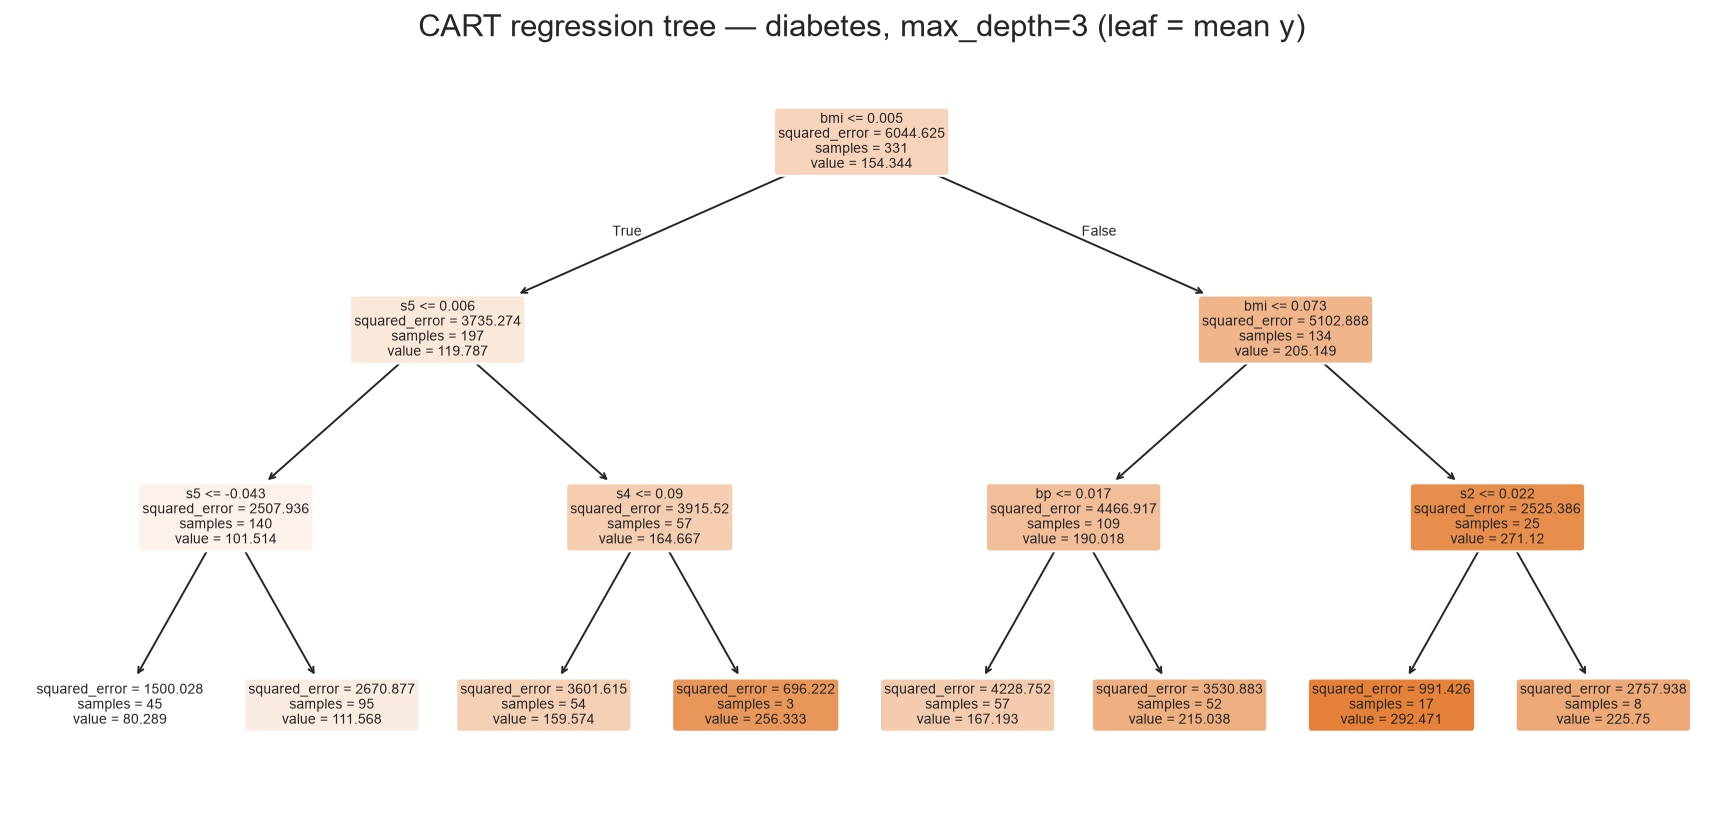

In [7]:
_rule("cell output")
diab = load_diabetes(as_frame=True)
Xr, yr = diab.data, diab.target
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.25, random_state=SEED)

reg = DecisionTreeRegressor(max_depth=3, random_state=SEED)
reg.fit(Xr_tr, yr_tr)
yp = reg.predict(Xr_te)
print("RMSE", round(np.sqrt(mean_squared_error(yr_te, yp)), 2), "R2", round(r2_score(yr_te, yp), 3))

fig, ax = plt.subplots(figsize=(12.5, 6.0))
plot_tree(reg, feature_names=list(Xr.columns), filled=True, rounded=True, fontsize=7, ax=ax)
ax.set_title("CART regression tree — diabetes, max_depth=3 (leaf = mean y)")
fig.tight_layout()
plt.show()


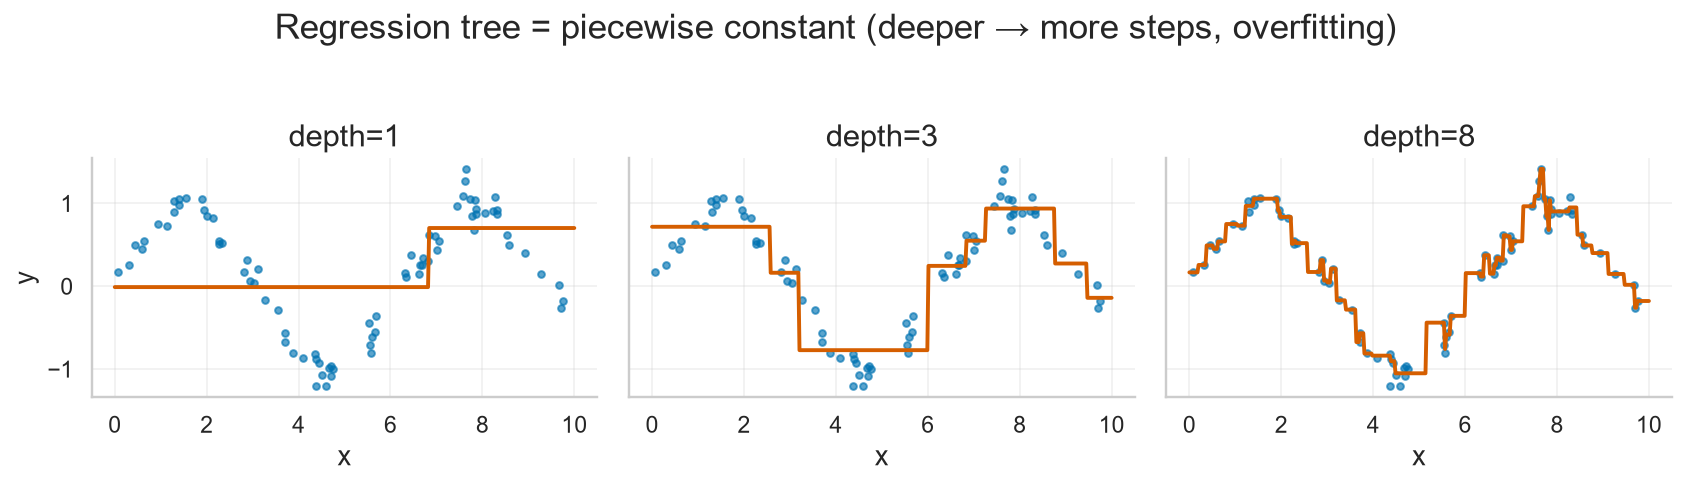

In [8]:
# 1-D regression cartoon: piecewise-constant fit
rng = np.random.default_rng(SEED)
xs = np.sort(rng.uniform(0, 10, 80))
ys = np.sin(xs) + rng.normal(0, 0.15, size=xs.shape)
xx = xs.reshape(-1, 1)
grid = np.linspace(0, 10, 400).reshape(-1, 1)
fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.3), sharey=True)
for ax, d in zip(axes, [1, 3, 8]):
    r = DecisionTreeRegressor(max_depth=d, random_state=SEED).fit(xx, ys)
    ax.scatter(xs, ys, s=12, alpha=0.65, c="C0")
    ax.plot(grid, r.predict(grid), color="C3", lw=2)
    ax.set_title(fr"depth={d}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
fig.suptitle("Regression tree = piecewise constant (deeper → more steps, overfitting)", y=1.05)
fig.tight_layout()
plt.show()


## 7. Take-home for the lab (Practical 05)

- Exam ID3: **multiway IG on Tennis**. sklearn trees: **binary CART**.
- Entropy vs Gini: similar rankings; say which **criterion** you used.
- Numerics: **thresholds**, not “bin then ID3” unless you justify bins.
- Always constrain **depth / $\alpha$** and report **test** metrics.

---
*End of lecture notebook. Kernel: `ml-lab-kernel`.*
